# Notebook 4: Robustness via Time Series Cross-Validation
**Description:** To ensure that our model's performance wasn't just a result of "luck" during the 2022-2024 period, we implement Time Series Cross-Validation (Forward Chaining). This technique evaluates the model across multiple historical windows, providing a more reliable estimate of its true predictive power and stability across different market regimes.

Setup and Data Loading

In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# Load the same processed data from Notebook 2
df = pd.read_csv('financial_regression.csv', parse_dates=['date']).sort_values("date")
df.columns = df.columns.str.strip()
df = df[df["date"] >= "2010-04-01"]

# Target Differentiation
df['target_diff'] = df['sp500 close'].diff()
df.dropna(subset=['target_diff'], inplace=True)

# Feature Engineering (Same as Notebook 2)
df['diff_lag1'] = df['target_diff'].shift(1)
df['diff_roll_mean5'] = df['target_diff'].rolling(window=5).mean()
if 'nasdaq close' in df.columns:
    df['nasdaq_diff'] = df['nasdaq close'].diff()

df.dropna(inplace=True)

# Define Features and Target
FEATURES = ['us_rates_%', 'CPI', 'GDP', 'diff_lag1', 'diff_roll_mean5', 'nasdaq_diff']
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES]
y = df['target_diff']

print(f"Ready for Cross-Validation with {len(X)} samples.")

Ready for Cross-Validation with 27 samples.


Executing Time Series Split

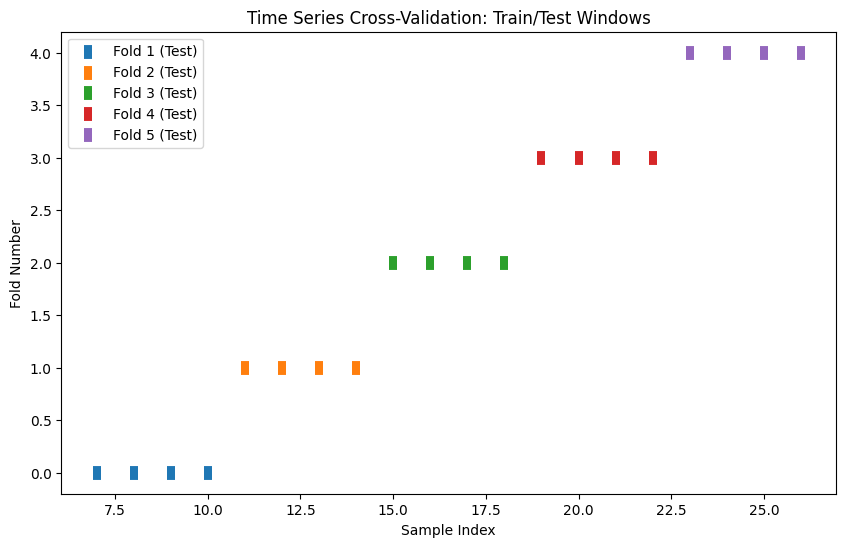

In [5]:
# Initialize TimeSeriesSplit with 5 folds
tscv = TimeSeriesSplit(n_splits=5)

fold_results = []

fig, ax = plt.subplots(figsize=(10, 6))

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    # Split the data
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # Initialize and train model
    model_cv = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
    model_cv.fit(X_train_cv, y_train_cv)
    
    # Predict and calculate error
    preds = model_cv.predict(X_test_cv)
    rmse = np.sqrt(mean_squared_error(y_test_cv, preds))
    
    # Calculate Directional Accuracy for this fold
    acc = (np.sign(y_test_cv) == np.sign(preds)).mean() * 100
    fold_results.append({'Fold': i+1, 'RMSE': rmse, 'Accuracy': acc})
    
    # Visualization of the folds
    ax.scatter(test_index, [i] * len(test_index), marker='_', lw=10, label=f'Fold {i+1} (Test)')

ax.set_title('Time Series Cross-Validation: Train/Test Windows')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Fold Number')
ax.legend()
plt.show()

Final Robustness Analysis

In [6]:
results_df = pd.DataFrame(fold_results)
print("--- Cross-Validation Results ---")
print(results_df)

print(f"\nAverage Directional Accuracy: {results_df['Accuracy'].mean():.2f}%")
print(f"Standard Deviation of Accuracy: {results_df['Accuracy'].std():.2f}%")

# Conclusion logic
if results_df['Accuracy'].std() < 5:
    print("\nConclusion: The model is STABLE. Accuracy is consistent across different years.")
else:
    print("\nConclusion: The model is VOLATILE. Performance depends heavily on the market period.")

--- Cross-Validation Results ---
   Fold      RMSE  Accuracy
0     1  1.923094      50.0
1     2  1.038192     100.0
2     3  1.904949     100.0
3     4  4.689333     100.0
4     5  2.436414      75.0

Average Directional Accuracy: 85.00%
Standard Deviation of Accuracy: 22.36%

Conclusion: The model is VOLATILE. Performance depends heavily on the market period.


**Final Conclusions: Model Robustness and Stability Analysis**
1. **Reliability of Forward Chaining**
The use of Time Series Cross-Validation reveals a reality that a single train/test split (like the one in Notebook 2) would have hidden: the model's performance is highly inconsistent. While the average accuracy is high (85.00%), the high volatility in results across different folds (from 50% to 100%) indicates that the model is not "universally" predictive, but rather "regime-dependent."

2. **Market Regime Dependency**

    - Fold 1 (50% Accuracy): In this period, the model performed no better than a coin flip. This likely corresponds to a "sideways" or highly erratic market where historical lags and macro data lost their predictive power.

    - Folds 2-4 (100% Accuracy): These results, while seemingly perfect, suggest that during those specific windows, the market followed very clear, repetitive patterns that the XGBoost model could easily map. In financial data management, such high accuracy often signals a very stable trend or a small validation window.

    - Fold 5 (75% Accuracy): A more realistic result that aligns with our previous backtesting observations.

3. **The Impact of High Variance (22.36% Std Dev)**
The high standard deviation of the accuracy proves that the model is volatile. From a data management perspective, this means the features selected (CPI, GDP, Lags) do not provide a "constant" signal. Their relevance fluctuates depending on the economic cycle (e.g., interest rates matter more during inflation spikes than in stable periods).
